# Travel Dataset
## Objetivo
Identificar el destino más popular entre usuarios de 25 a 35 años y evaluar, entre estos destinos, cuál presenta el menor costo total promedio por viaje, considerando la suma del precio del vuelo y la reservación de hotel.
## Proceso de análisis
El análisis se desarrolló a través de las siguientes etapas:

### Exploración inicial
- Revisión general de los datasets
- Identificación de valores nulos y comprensión de la estructura de los datos
### Limpieza y preparación de datos
- Conversión de tipos de datos
- Renombramiento de columnas para mayor claridad
- Detección y tratamiento de valores duplicados (exactos y lógicos)
- Estandarización de variables categóricas
- Validación de consistencia en variables numéricas
### Selección y validación de variables
- Selección de columnas relevantes para el análisis
- Evaluación de rangos de variables y outliers
### Análisis exploratorio de datos (EDA)
- Identificación de patrones, tendencias y comportamientos
- Análisis orientado a negocio
- Filtrado de datos según criterios relevantes
### Integración de datos
- Validación de la integridad entre tablas (relaciones entre datasets)
### Visualización
- Construcción de gráficos para facilitar la interpretación de los datos

## Carga de datos y librerías

In [1]:
#importar librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#importar dataset
flights_raw=pd.read_csv(r"C:\Users\josem\OneDrive\Escritorio\DATA ANALYST\PROYECTOS PRUEBA\latam_travels\data\flights.csv")
hotels_raw=pd.read_csv(r"C:\Users\josem\OneDrive\Escritorio\DATA ANALYST\PROYECTOS PRUEBA\latam_travels\data\hotels.csv")
users_raw=pd.read_csv(r"C:\Users\josem\OneDrive\Escritorio\DATA ANALYST\PROYECTOS PRUEBA\latam_travels\data\users.csv")

## Exploración inicial de datos

In [3]:
#Exploracion de datos
flights_raw.info()
flights_raw.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [4]:
print("Nulos implicitos en flights: ")
print(flights_raw.isna().sum())
print("Nulos totales: ")
print(flights_raw.isna().sum().sum())

Nulos implicitos en flights: 
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64
Nulos totales: 
0


### Consideraciones
* No hay presencia de nulos aparentes
* Cambiar el tipo de dato en la columna date a datetime
* Cambiar titulos de columnas a snake_case

In [5]:
hotels_raw.info()
hotels_raw.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 2.5+ MB


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [6]:
print("Nulos implicitos en hotels: ")
print(hotels_raw.isna().sum())
print("Nulos totales: ")
print(hotels_raw.isna().sum().sum())

Nulos implicitos en hotels: 
travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64
Nulos totales: 
0


### Consideraciones
* No hay presencia de nulos aparentes
* Cambiar el tipo de dato en la columna date a datetime
* Cambiar titulos de columnas a snake_case

In [7]:
users_raw.info()
users_raw.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [8]:
print("Nulos implicitos en users: ")
print(users_raw.isna().sum())
print("Nulos totales: ")
print(users_raw.isna().sum().sum())

Nulos implicitos en users: 
code       0
company    0
name       0
gender     0
age        0
dtype: int64
Nulos totales: 
0


### Consideraciones
* No hay presencia de nulos aparentes


## Limpieza y preparación de datos


### Transformación tipo de datos

In [9]:
#Cambiar formato de las columnas date
flights_raw["date"] = pd.to_datetime(flights_raw["date"])
hotels_raw["date"] = pd.to_datetime(hotels_raw["date"])

### Renombrar columnas

In [10]:
#Formato snake_case en columnas
flights_raw=flights_raw.rename(columns={"travelCode":"travel_code",\
                                "userCode":"user_code",\
                                "flightType":"flight_type"})

hotels_raw=hotels_raw.rename(columns={"travelCode":"travel_code",\
                              "userCode":"user_code"})
#Confirmamos cambios de titulo y formato fecha
flights_raw.info()
hotels_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   travel_code  271888 non-null  int64         
 1   user_code    271888 non-null  int64         
 2   from         271888 non-null  object        
 3   to           271888 non-null  object        
 4   flight_type  271888 non-null  object        
 5   price        271888 non-null  float64       
 6   time         271888 non-null  float64       
 7   distance     271888 non-null  float64       
 8   agency       271888 non-null  object        
 9   date         271888 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 20.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 

### Valores duplicados

In [11]:
#Encontrar valores duplicados generales
print(f"""
Duplicados:
Flights: {flights_raw.duplicated().sum()}
Hotels: {hotels_raw.duplicated().sum()}
Users: {users_raw.duplicated().sum()}
""")


Duplicados:
Flights: 0
Hotels: 0
Users: 0



#### Consideraciones
* Los dataframes no cuentan con valores duplicados

In [12]:
flights=flights_raw.copy()
hotels=hotels_raw.copy()
users=users_raw.copy()

#### Consideraciones
* El dataframe de users ahora cuenta con filas unicas por cada cliente
* En flights se intuye que la combinación ("user_code","from","to","date") debe ser único.
* hotels podrá tener duplicado implicitos considerando que un usuario pudo hacer mas de 1 reservación para otras personas

In [13]:
#Comprobamos hipotesis de comportamiento de usuarios en flights
flights.duplicated(subset=["user_code","from","to","date"]).sum()

np.int64(0)

#### Conlusiones
* En el dataset flights, se evaluó la combinación de variables "user_code","from","to","date" con el objetivo de identificar posibles duplicados lógicos.
Bajo esta hipótesis, un mismo usuario no debería registrar múltiples vuelos con la misma ruta en la misma fecha.
El análisis no arrojó registros duplicados bajo este criterio, lo que sugiere consistencia en los datos y ausencia de recompras duplicadas o errores evidentes en esta dimensión.

## Estandarización de variables categóricas y numéricas

Se revisa la consistencia en las variables categóricas y numéricas de cada Dataset

### Flights

In [14]:
# Revisar valores unicos en "from", "to" 
print(f"from_unique: {flights["from"].unique()}")
print(f"to_unique: {flights["to"].unique()}")

from_unique: ['Recife (PE)' 'Florianopolis (SC)' 'Brasilia (DF)' 'Aracaju (SE)'
 'Salvador (BH)' 'Campo Grande (MS)' 'Sao Paulo (SP)' 'Natal (RN)'
 'Rio de Janeiro (RJ)']
to_unique: ['Florianopolis (SC)' 'Recife (PE)' 'Brasilia (DF)' 'Salvador (BH)'
 'Aracaju (SE)' 'Campo Grande (MS)' 'Sao Paulo (SP)' 'Natal (RN)'
 'Rio de Janeiro (RJ)']


In [15]:
#Revisar consistencia en el formato de decimales "price"
flights["price"].astype(str).str.contains(",", na=False).sum()

np.int64(0)

#### Conclusiones
* Las variables categóricas y numéricas son consistentes en formato para el dataset de flights

### Hotels

In [16]:
# Revisar valores unicos en "place"
print(f"place_unique: {hotels["place"].unique()}")

place_unique: ['Florianopolis (SC)' 'Salvador (BH)' 'Natal (RN)' 'Aracaju (SE)'
 'Recife (PE)' 'Sao Paulo (SP)' 'Campo Grande (MS)' 'Rio de Janeiro (RJ)'
 'Brasilia (DF)']


In [17]:
#Revisar consistencia en el formato de decimales "price" y "total"
print(f"price_format: {hotels["price"].astype(str).str.contains(",", na=False).sum()}")
print(f"total_format: {hotels["total"].astype(str).str.contains(",", na=False).sum()}")

price_format: 0
total_format: 0


#### Conclusiones
* Las variables categóricas y numéricas son consistentes en formato para el dataset de flights

### Users

In [18]:
# Revisar valores unicos en "gender"
print(f"gender_unique: {users["gender"].unique()}")

gender_unique: ['male' 'female' 'none']


In [19]:
#Cantidad de "none" en "gender"
(users["gender"]=="none").sum()

np.int64(440)

#### Conclusiones
* Las variables categóricas son consistentes
* Los valores "none" en la variable gender fueron conservados, ya que pueden representar usuarios que prefieren no especificar su género o identificarse fuera de las categorías tradicionales.

## Selección y validación de variables

### Columnas relevantes


Para fines de este analisis se consideran relevantes las siguientes columnas
* flights = 'travel_code', 'user_code', 'from', 'to','price','date'
* hotels = 'travelCode', 'userCode','place', 'days', 'price', 'total', 'date'
* users = 'code', 'gender', 'age'

In [20]:
#Selección de columnas relevantes
flights_short=flights[['travel_code', 'user_code', 'from', 'to','price','date']].copy()
hotels_short=hotels[['travel_code', 'user_code','place', 'days', 'price', 'total', 'date']].copy()
users_short=users[['code', 'gender', 'age']].copy()

### Validacion de rangos y outliers

#### Flights

In [21]:
#Estadistica inicial de flights
flights_short.describe()

,travel_code,user_code,price,date
count,271888.000000,271888.000000,271888.00000,271888
mean,67971.500000,667.505495,957.37503,2021-01-11 05:25:56.052492032
min,0.000000,0.000000,301.51000,2019-09-26 00:00:00
25%,33985.750000,326.000000,672.66000,2020-04-02 00:00:00
50%,67971.500000,659.000000,904.00000,2020-11-14 00:00:00
75%,101957.250000,1011.000000,1222.24000,2021-09-09 00:00:00
max,135943.000000,1339.000000,1754.17000,2023-07-24 00:00:00
std,39243.724665,389.523127,362.31189,NaN


Se analizará si existe una consitencia en los datos registrados entre cada año

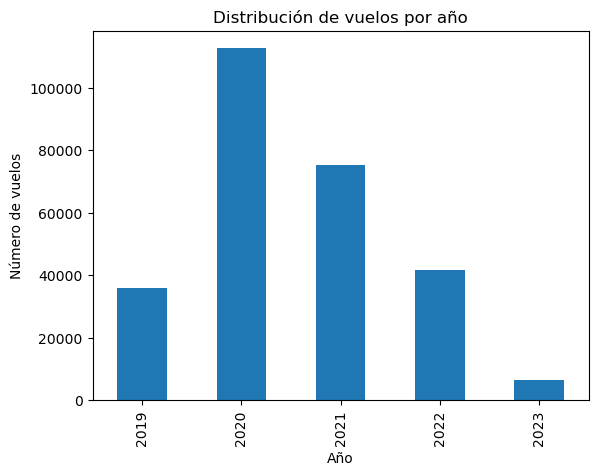

In [22]:
#Distribución temporal de los vuelos
flights_short["date"].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title("Distribución de vuelos por año")
plt.xlabel("Año")
plt.ylabel("Número de vuelos")

plt.show()

In [23]:
# Cantidad de vuelos registrados anualmente
flights_short["date"].dt.year.value_counts().sort_index()

date
2019     35826
2020    112571
2021     75363
2022     41761
2023      6367
Name: count, dtype: int64

##### Conclusiones
* Existe un mayor registro de vuelos en 2020 comparado con el resto de los años, analizará posibles duplicados o errores en ese año
* El año 2023 cuenta con muy pocos registros, la hipótesis es que el dataset se realizo antes de conlcuir el año 2023, se analizará si los datos del dataset no contempla la totalidad de ese año

In [24]:
#Meses de los registros del año 2023
flights_short[flights_short["date"].dt.year == 2023]["date"].dt.month.value_counts().sort_index()

date
1    1701
2    1378
3    1296
4     890
5     592
6     381
7     129
Name: count, dtype: int64

##### Conclusiones
* El dataset no considera todo el año 2023
* Para fines del análisis se contemplará los registros del 2023 para ampliar la muestra y encontrar el destino mas popular y el más economico.


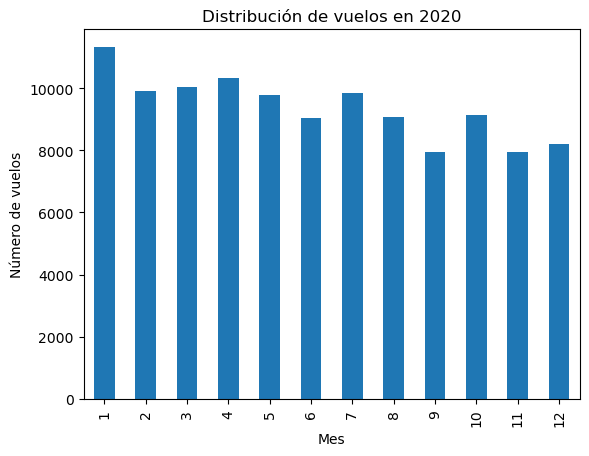

In [25]:
#Temporalidad de vuelos durante el 2020
flights_short[flights_short["date"].dt.year == 2020]["date"].dt.month.value_counts().sort_index().plot(kind='bar',x="flights_year")
plt.title("Distribución de vuelos en 2020")
plt.xlabel("Mes")
plt.ylabel("Número de vuelos")

plt.show()

##### Conclusiones
* No existen datos atípicos dentro del comportameinto de vuelos dentro del 2020.

In [26]:
#Cantidad de usuarios unicos por año
flights_short.groupby(flights_short["date"].dt.year)["user_code"].nunique()

date
2019    1335
2020    1233
2021     899
2022     565
2023     216
Name: user_code, dtype: int64

In [27]:
#Cantidad de vuelos unicos por año
flights_short.groupby(flights_short["date"].dt.year)["travel_code"].nunique()

date
2019    17913
2020    56735
2021    38348
2022    21150
2023     3236
Name: travel_code, dtype: int64

##### Conlusiones
* Se observa un crecimiento significativo en el número de usuarios únicos durante el año 2020. Sin embargo, a partir de ese punto, la tendencia comienza a descender progresivamente hasta 2023.
* Es importante considerar que los datos de 2023 solo abarcan hasta el mes de julio. Aun así, tanto el número de usuarios únicos como el volumen de vuelos registrados muestran niveles considerablemente más bajos en comparación con años anteriores.
* Este comportamiento podría indicar una posible pérdida de usuarios o una disminución en la demanda del servicio.

##### Distribución de precios
Se analizará la distribución de los precios por cada año buscando identificar si se cuenta con rangos válidos.

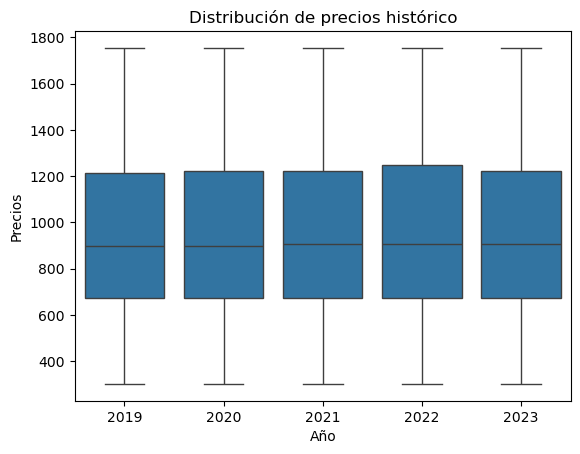

In [28]:
# Crear columna año
flights_short["year"]= flights_short["date"].dt.year
# Gráfico
sns.boxplot(x="year", y="price", data=flights_short)	
plt.title("Distribución de precios histórico")
plt.xlabel("Año")
plt.ylabel("Precios")
plt.show()

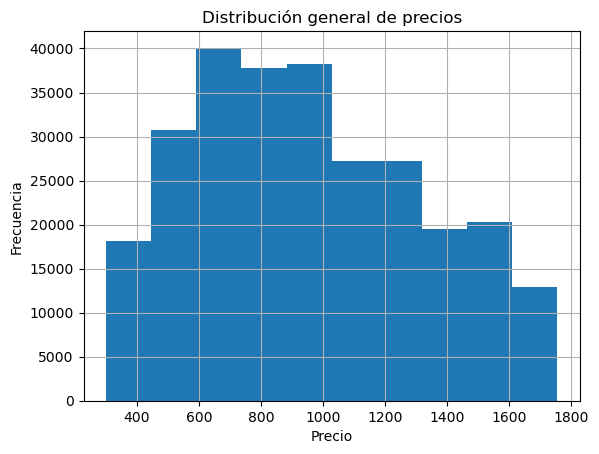

In [29]:
#Distibución de los precios
flights_short["price"].hist(bins=10)
plt.title("Distribución general de precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

##### Conlcusiones
* El análisis de la distribución de precios a lo largo de los años muestra que no existen cambios significativos en la mediana ni en la dispersión de los precios. Esto sugiere que los precios se han mantenido relativamente estables en el tiempo.
* Dado que no se observan variaciones relevantes en los precios, es poco probable que estos sean el principal factor que explique la disminución en el número de usuarios.


#### Hotels

In [30]:
#Estadistica inicial de Hotels
hotels_short.describe()

,travel_code,user_code,days,price,total,date
count,40552.000000,40552.000000,40552.000000,40552.000000,40552.000000,40552
mean,67911.794461,666.963726,2.499679,214.439554,536.229513,2021-01-10 05:22:32.219372544
min,0.000000,0.000000,1.000000,60.390000,60.390000,2019-09-26 00:00:00
25%,33696.750000,323.000000,1.000000,165.990000,247.620000,2020-04-02 00:00:00
50%,67831.000000,658.000000,2.000000,242.880000,495.240000,2020-11-12 00:00:00
75%,102211.250000,1013.000000,4.000000,263.410000,742.860000,2021-09-09 00:00:00
max,135942.000000,1339.000000,4.000000,313.020000,1252.080000,2023-07-13 00:00:00
std,39408.199333,391.136794,1.119326,76.742305,319.331482,NaN


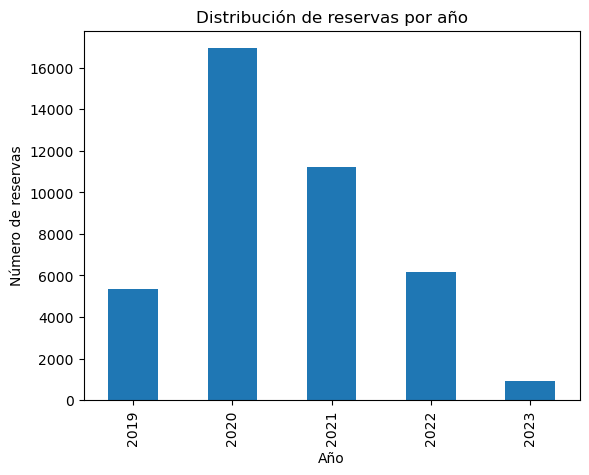

In [31]:
#Distribución temporal de los reservas
hotels_short["date"].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title("Distribución de reservas por año")
plt.xlabel("Año")
plt.ylabel("Número de reservas")

plt.show()

In [32]:
# Cantidad de reservas registrados anualmente
hotels_short["date"].dt.year.value_counts().sort_index()

date
2019     5326
2020    16929
2021    11194
2022     6161
2023      942
Name: count, dtype: int64

##### Distribución de precios
Se analizará la distribución de los precios por cada año buscando identificar si se cuenta con rangos válidos.

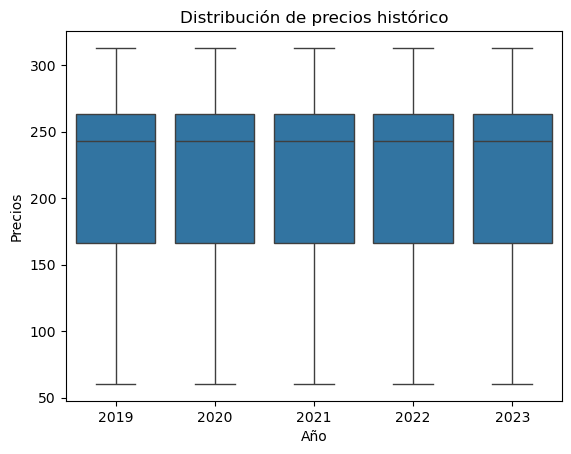

In [33]:
# Crear columna año
hotels_short["year"]= hotels_short["date"].dt.year
# Gráfico
sns.boxplot(x="year", y="price", data=hotels_short)	
plt.title("Distribución de precios histórico")
plt.xlabel("Año")
plt.ylabel("Precios")
plt.show()

##### Conlcusiones
* El análisis de la distribución de precios a lo largo de los años muestra que no existen cambios significativos en la mediana ni en la dispersión de los precios. Esto sugiere que los precios se han mantenido relativamente estables en el tiempo.
* El comportamiento de reservas de hotel es correlativo con la tendencia de los vuelos.
* Las reservas de hotel van desde 1 a 4 dias lo cual representa un comportamiento común.

#### Users


Se analizará la distribución de edad de los usuarios y la detección de outliers

In [34]:
#Estadistica inicial de Users
users_short.describe()

,code,age
count,1340.000000,1340.000000
mean,669.500000,42.742537
std,386.968991,12.869779
min,0.000000,21.000000
25%,334.750000,32.000000
50%,669.500000,42.000000
75%,1004.250000,54.000000
max,1339.000000,65.000000


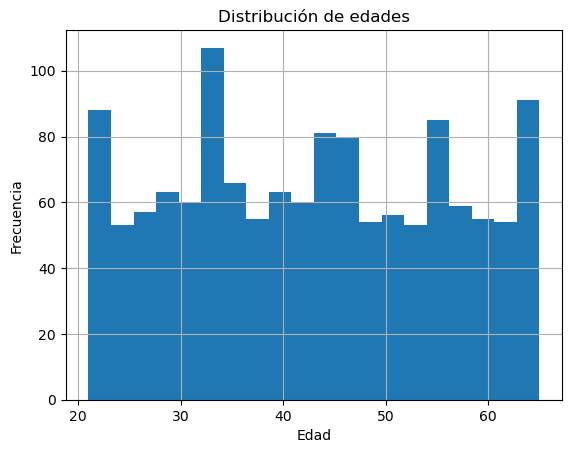

In [35]:
#Distribución de edades
users_short["age"].hist(bins=20)

plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

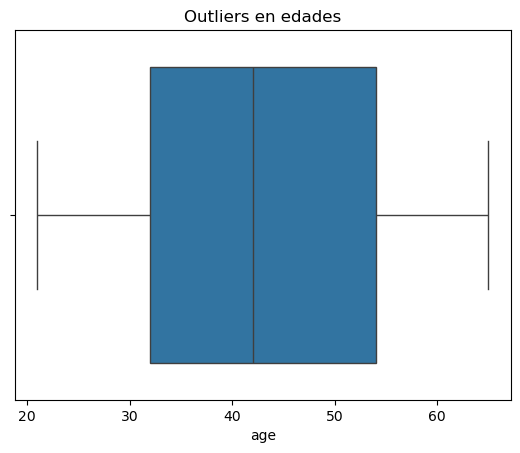

In [36]:
#Detección de outliers
sns.boxplot(x=users_short["age"])

plt.title("Outliers en edades")

plt.show()

##### Conlcusiones
* Los rangos de edad son consistentes y no se cuenta con outliers
* La edad de los usuarios va de entre los 21 años y los 65
* Las personas entre 30 y 40 son los que mas viajan.

## Análisis exploratorio de datos (EDA)

### Flights

In [37]:
#Numero de viajes que realiza un usuario
trips_per_user=flights_short.groupby("user_code")["travel_code"].nunique().sort_values(ascending=False)
print(trips_per_user)

user_code
571     200
422     200
766     200
1089    200
1026    200
       ... 
910       1
463       1
647       1
1075      1
1016      1
Name: travel_code, Length: 1335, dtype: int64


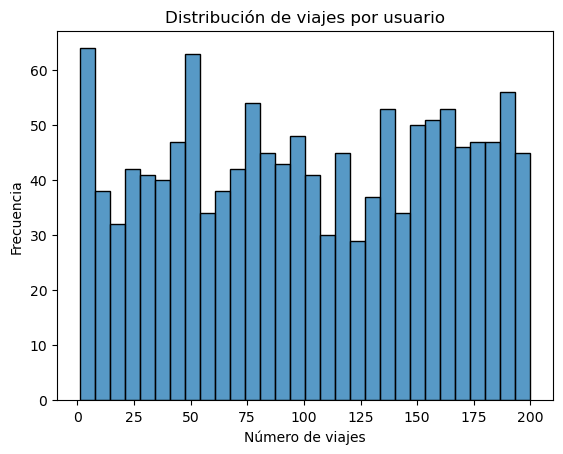

In [38]:
sns.histplot(trips_per_user, bins=30)

plt.title("Distribución de viajes por usuario")
plt.xlabel("Número de viajes")
plt.ylabel("Frecuencia")

plt.show()

##### Conclusiones
* Aunque existen usuarios con hasta 200 viajes, la distribución uniforme de los datos sugiere que este comportamiento podría no ser representativo de un escenario real.
* Un travel_code tiene multiples registros, contempla el viaje completo ya sea vuelo a un destino con conexiones o un viaje redondo.

In [39]:
#Se analiza el numero mínimo y máximo de travel_code existentes
print(f"Cantidad mínima de vuelos por código de viaje: {flights_short["travel_code"].value_counts().min()}")
print("")
print(f"Cantidad máxima de vuelos por código de viaje: {flights_short["travel_code"].value_counts().max()}")

Cantidad mínima de vuelos por código de viaje: 2

Cantidad máxima de vuelos por código de viaje: 2


##### Conclusiones
* El dataset presenta una estructura simplificada en la que todos los viajes son redondos y no existen conexiones, lo cual no refleja completamente la complejidad de escenarios reales.


Analizar cuantos vuelos son de viajes redondos para entender el patrón de "travel_code"

In [40]:
#Ordenar los códigos de viaje de cada usuario por fecha
flights_short = flights_short.sort_values(by=["travel_code", "user_code", "date"])

In [41]:
#Crear un df con cada segmento del viaje unido en una sola fila
#Agrupar los códigos de viaje de cada usuario
#Agregar una columna de origen que toma el primer valor de la columna from
#Agregar una columna de destino con el último valor de la columna from
trip_summary = flights_short.groupby(['travel_code', 'user_code']).agg(
    origin=('from', 'first'),
    final_destination=('to', 'last')
)

In [42]:
#Crear la columna de validación de vuelo redondo
trip_summary["round_trip"] = trip_summary["origin"] == trip_summary["final_destination"]

In [43]:
#Contar la cantidad de vuelos redondos
trip_summary["round_trip"].value_counts()

round_trip
True    135944
Name: count, dtype: int64

##### Conclusiones
* Todos los códigos de viaje representan viajes redondos, ya que el origen y el destino final coinciden en todos los casos analizados.
* A partir de esto se analizarán los destinos mas populares de los usuarios

##### Consideraciones
* Cada travel_code se repite únicamente 2 veces y todos los travel_code representan viajes redondos por lo que cada usuarios viajo de ida y vuelta sin tener conexiones en su viaje, al ordenar los códigos de viaje de cada usuario por fecha se sabe cual de los vuelos fue de ida y cual el de regreso.

In [44]:
#Filtrar solo los vuelos de ida
#keep='first' toma el primer valor como original "False", ~ invierte la logica para obtener los de ida
flights_one_way=flights_short[~flights_short["travel_code"].duplicated(keep='first')]
flights_one_way.head(20)

,travel_code,user_code,from,to,price,date,year
0,0,0,Recife (PE),Florianopolis (SC),1434.38,2019-09-26,2019
2,1,0,Brasilia (DF),Florianopolis (SC),1487.52,2019-10-03,2019
4,2,0,Aracaju (SE),Salvador (BH),1684.05,2019-10-10,2019
6,3,0,Aracaju (SE),Campo Grande (MS),743.54,2019-10-17,2019
8,4,0,Recife (PE),Florianopolis (SC),803.39,2019-10-24,2019
10,5,0,Brasilia (DF),Aracaju (SE),1287.52,2019-10-31,2019
12,6,0,Recife (PE),Florianopolis (SC),1070.54,2019-11-07,2019
14,7,0,Aracaju (SE),Salvador (BH),964.83,2019-11-14,2019
16,8,0,Recife (PE),Sao Paulo (SP),513.06,2019-11-21,2019
18,9,0,Brasilia (DF),Campo Grande (MS),583.60,2019-11-28,2019


In [45]:
#vuelos de regreso
flights_return=flights_short[flights_short["travel_code"].duplicated(keep='first')]
flights_return.head()

,travel_code,user_code,from,to,price,date,year
1,0,0,Florianopolis (SC),Recife (PE),1292.29,2019-09-30,2019
3,1,0,Florianopolis (SC),Brasilia (DF),1127.36,2019-10-04,2019
5,2,0,Salvador (BH),Aracaju (SE),1531.92,2019-10-12,2019
7,3,0,Campo Grande (MS),Aracaju (SE),877.56,2019-10-20,2019
9,4,0,Florianopolis (SC),Recife (PE),695.30,2019-10-26,2019


### Hotels

Verificar cuantas reservas de hoteles existen por cada código de viaje

In [46]:
hotels_short["travel_code"].duplicated().sum()

np.int64(0)

##### Conclusiones
* Por cada código de viaje solo existe una reservación

## Análisis orientado a negocio

Se analizará cuales son los destino mas populares entre las personas de 25 a 35 años y cual de estos es mas económico considerando un viaje con una estancia promedio.


### Integración de datos

In [47]:
#Usuarios entre 25 y 35 años (incluyente)
users_young=users_short[users_short["age"].between(25, 35)]

In [48]:
#Unión de tablas
user_young_oneway=pd.merge(
    flights_one_way,
    users_young,
    left_on="user_code",
    right_on="code",
    how="inner"
)


In [49]:
#Verificamos duplilcados
user_young_oneway["travel_code"].duplicated().sum()

np.int64(0)

In [50]:
hotels_short.head()

,travel_code,user_code,place,days,price,total,date,year
0,0,0,Florianopolis (SC),4,313.02,1252.08,2019-09-26,2019
1,2,0,Salvador (BH),2,263.41,526.82,2019-10-10,2019
2,7,0,Salvador (BH),3,263.41,790.23,2019-11-14,2019
3,11,0,Salvador (BH),4,263.41,1053.64,2019-12-12,2019
4,13,0,Florianopolis (SC),1,313.02,313.02,2019-12-26,2019


In [51]:
travel_young_oneway=pd.merge(
    user_young_oneway,
    hotels_short,
    on=['travel_code'], how='inner')
travel_young_oneway.head()

,travel_code,user_code_x,from,to,price_x,date_x,year_x,code,gender,age,user_code_y,place,days,price_y,total,date_y,year_y
0,997,9,Brasilia (DF),Sao Paulo (SP),992.17,2019-09-26,2019,9,none,35,9,Sao Paulo (SP),4,139.10,556.40,2019-09-26,2019
1,998,9,Aracaju (SE),Natal (RN),549.96,2019-10-03,2019,9,none,35,9,Natal (RN),2,242.88,485.76,2019-10-03,2019
2,999,9,Aracaju (SE),Florianopolis (SC),1174.97,2019-10-10,2019,9,none,35,9,Florianopolis (SC),3,313.02,939.06,2019-10-10,2019
3,1006,9,Aracaju (SE),Recife (PE),1124.11,2019-11-28,2019,9,none,35,9,Recife (PE),2,312.83,625.66,2019-11-28,2019
4,1007,9,Recife (PE),Aracaju (SE),1166.10,2019-12-05,2019,9,none,35,9,Aracaju (SE),2,208.04,416.08,2019-12-05,2019


In [52]:
#Verificamos duplilcados
travel_young_oneway["travel_code"].duplicated().sum()

np.int64(0)

In [53]:
#Dar formato a la tabla
travel_young_oneway = travel_young_oneway.drop(
    columns=["user_code_y", "date_y","year_y","total","year_x","year_y","code","place"]
)

travel_young_oneway = travel_young_oneway.rename(columns={
    "user_code_x": "user_code",
    "to": "destination",
    "price_x":"flight_price",
    "date_x":"date",
    "price_y":"hotel_price"
})
travel_young_oneway.columns

Index(['travel_code', 'user_code', 'from', 'destination', 'flight_price',
       'date', 'gender', 'age', 'days', 'hotel_price'],
      dtype='object')

In [54]:
travel_young_oneway=travel_young_oneway[
    [
        "travel_code",
        "user_code",
        "gender",
        "age",
        "from",
        "destination",
        "date",
        "days",
        "flight_price",
        "hotel_price"
    ]
]

In [55]:
travel_young_oneway.head()

,travel_code,user_code,gender,age,from,destination,date,days,flight_price,hotel_price
0,997,9,none,35,Brasilia (DF),Sao Paulo (SP),2019-09-26,4,992.17,139.10
1,998,9,none,35,Aracaju (SE),Natal (RN),2019-10-03,2,549.96,242.88
2,999,9,none,35,Aracaju (SE),Florianopolis (SC),2019-10-10,3,1174.97,313.02
3,1006,9,none,35,Aracaju (SE),Recife (PE),2019-11-28,2,1124.11,312.83
4,1007,9,none,35,Recife (PE),Aracaju (SE),2019-12-05,2,1166.10,208.04


In [56]:
#Promedio de dias en un viaje
travel_young_oneway["days"].mean()

np.float64(2.4970800752251807)

##### Consideraciones
Se define como viaje promedio una estancia de 3 días y 2 noches para el segmento de usuarios de 25 a 35 años. En consecuencia, el costo del hotel se estandariza a 2 noches por viaje, permitiendo una comparación consistente del costo total (vuelo + hospedaje) entre destinos.

In [57]:
travel_young_oneway["mean_days_price"]=travel_young_oneway["hotel_price"]*2

In [58]:
travel_young_oneway.head()

,travel_code,user_code,gender,age,from,destination,date,days,flight_price,hotel_price,mean_days_price
0,997,9,none,35,Brasilia (DF),Sao Paulo (SP),2019-09-26,4,992.17,139.10,278.20
1,998,9,none,35,Aracaju (SE),Natal (RN),2019-10-03,2,549.96,242.88,485.76
2,999,9,none,35,Aracaju (SE),Florianopolis (SC),2019-10-10,3,1174.97,313.02,626.04
3,1006,9,none,35,Aracaju (SE),Recife (PE),2019-11-28,2,1124.11,312.83,625.66
4,1007,9,none,35,Recife (PE),Aracaju (SE),2019-12-05,2,1166.10,208.04,416.08


In [59]:
#Añadir los precios de los vuelos de regreso
flights_return = flights_return.drop(
    columns=["user_code","from","to","date","year"]
)

flights_return=flights_return.rename(columns={
    "price": "return_price"})


In [60]:
travel_young=pd.merge(
    travel_young_oneway,
    flights_return,
    on=['travel_code'], how='inner')

travel_young["total_flight_price"]=travel_young["flight_price"]+travel_young["return_price"]

In [61]:
travel_young.head()

,travel_code,user_code,gender,age,from,destination,date,days,flight_price,hotel_price,mean_days_price,return_price,total_flight_price
0,997,9,none,35,Brasilia (DF),Sao Paulo (SP),2019-09-26,4,992.17,139.10,278.20,824.31,1816.48
1,998,9,none,35,Aracaju (SE),Natal (RN),2019-10-03,2,549.96,242.88,485.76,611.40,1161.36
2,999,9,none,35,Aracaju (SE),Florianopolis (SC),2019-10-10,3,1174.97,313.02,626.04,1149.53,2324.50
3,1006,9,none,35,Aracaju (SE),Recife (PE),2019-11-28,2,1124.11,312.83,625.66,1166.10,2290.21
4,1007,9,none,35,Recife (PE),Aracaju (SE),2019-12-05,2,1166.10,208.04,416.08,1124.11,2290.21


In [62]:
travel_young["total_travel"]=travel_young["mean_days_price"]+travel_young["total_flight_price"]

## Visualización

In [63]:
travel_young.head()

,travel_code,user_code,gender,age,from,destination,date,days,flight_price,hotel_price,mean_days_price,return_price,total_flight_price,total_travel
0,997,9,none,35,Brasilia (DF),Sao Paulo (SP),2019-09-26,4,992.17,139.10,278.20,824.31,1816.48,2094.68
1,998,9,none,35,Aracaju (SE),Natal (RN),2019-10-03,2,549.96,242.88,485.76,611.40,1161.36,1647.12
2,999,9,none,35,Aracaju (SE),Florianopolis (SC),2019-10-10,3,1174.97,313.02,626.04,1149.53,2324.50,2950.54
3,1006,9,none,35,Aracaju (SE),Recife (PE),2019-11-28,2,1124.11,312.83,625.66,1166.10,2290.21,2915.87
4,1007,9,none,35,Recife (PE),Aracaju (SE),2019-12-05,2,1166.10,208.04,416.08,1124.11,2290.21,2706.29


Ciudades más visitadas

In [64]:
top_cities=travel_young["destination"].value_counts().reset_index()
top_cities.columns = ["destination", "total_visits"]

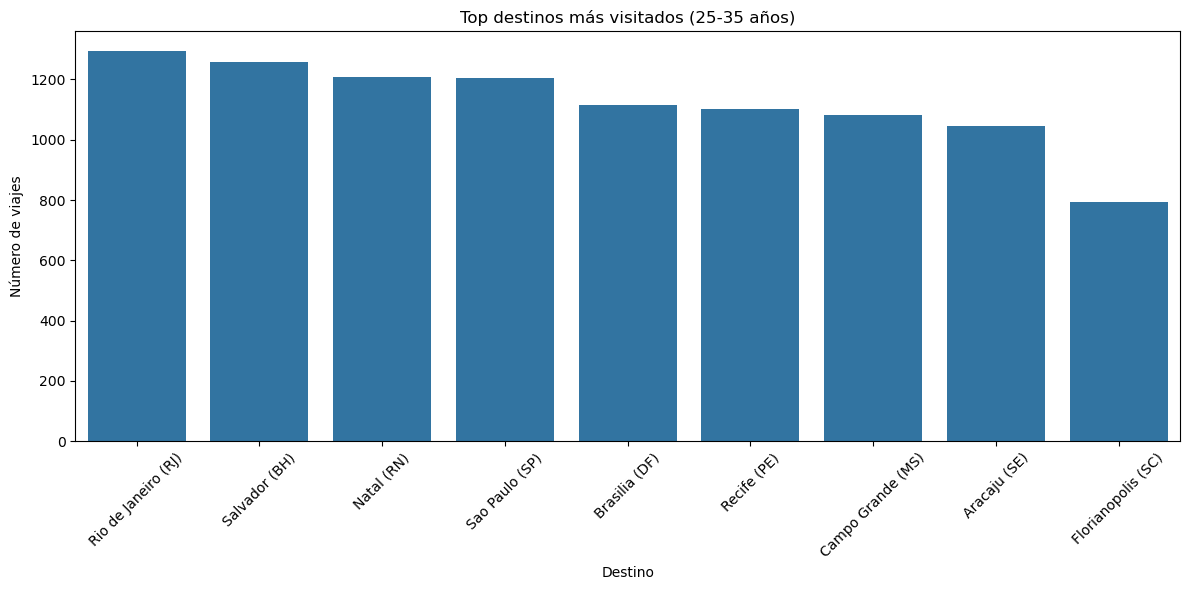

In [65]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_cities,
    x="destination",
    y="total_visits"
)
plt.title("Top destinos más visitados (25-35 años)")
plt.xlabel("Destino")
plt.ylabel("Número de viajes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [66]:
cheap_cities = (
    travel_young.groupby("destination", as_index=False)["total_travel"]
    .median()
    .sort_values("total_travel")
)

cheap_cities.columns = ["destination", "median_total_price"]
print(cheap_cities)

           destination  median_total_price
6  Rio de Janeiro (RJ)             1823.45
2    Campo Grande (MS)             1865.77
8       Sao Paulo (SP)             2094.05
4           Natal (RN)             2119.59
1        Brasilia (DF)             2237.93
5          Recife (PE)             2441.51
0         Aracaju (SE)             2633.86
7        Salvador (BH)             2844.21
3   Florianopolis (SC)             2866.70


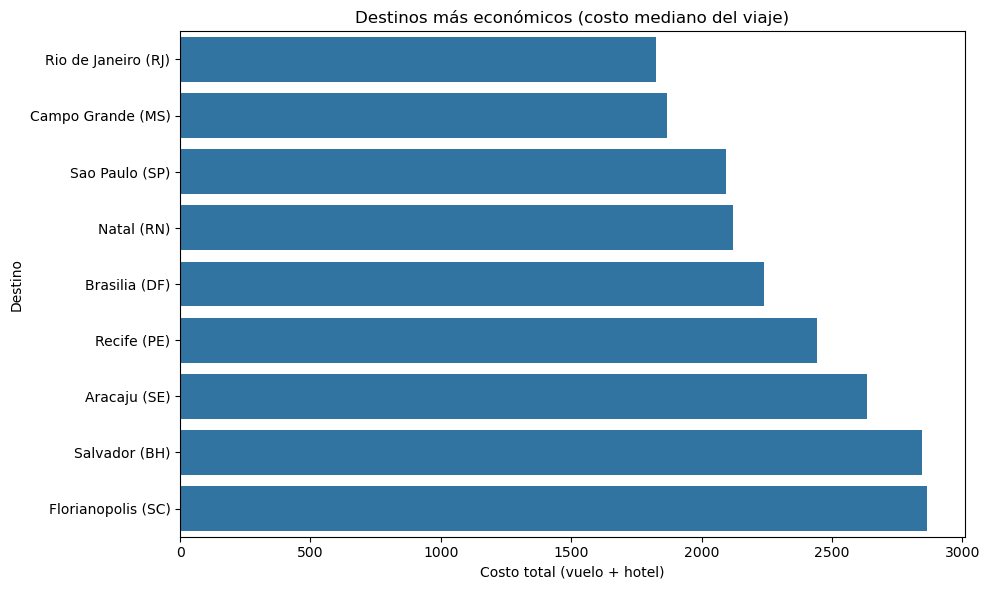

In [67]:
 plt.figure(figsize=(10,6))

sns.barplot(
    data=cheap_cities,
    x="median_total_price",
    y="destination"
)

plt.title("Destinos más económicos (costo mediano del viaje)")
plt.xlabel("Costo total (vuelo + hotel)")
plt.ylabel("Destino")

plt.tight_layout()
plt.show()

##### Conslusiones
* Rio de Janeiro es el destino más popular entre los usuarios siendo igual el mas económico para una viaje redondo con 2 días de hospedaje

In [68]:
#Precios por mes para viajar a Rio de Janeiro
rio_data=travel_young[travel_young["destination"]=="Rio de Janeiro (RJ)"]
rio_data["month"] = rio_data["date"].dt.month

monthly_prices = (
    rio_data.groupby("month", as_index=False)["total_travel"]
    .median()
    .sort_values("month")
)

C:\Users\josem\AppData\Local\Temp\ipykernel_16956\2786040607.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rio_data["month"] = rio_data["date"].dt.month


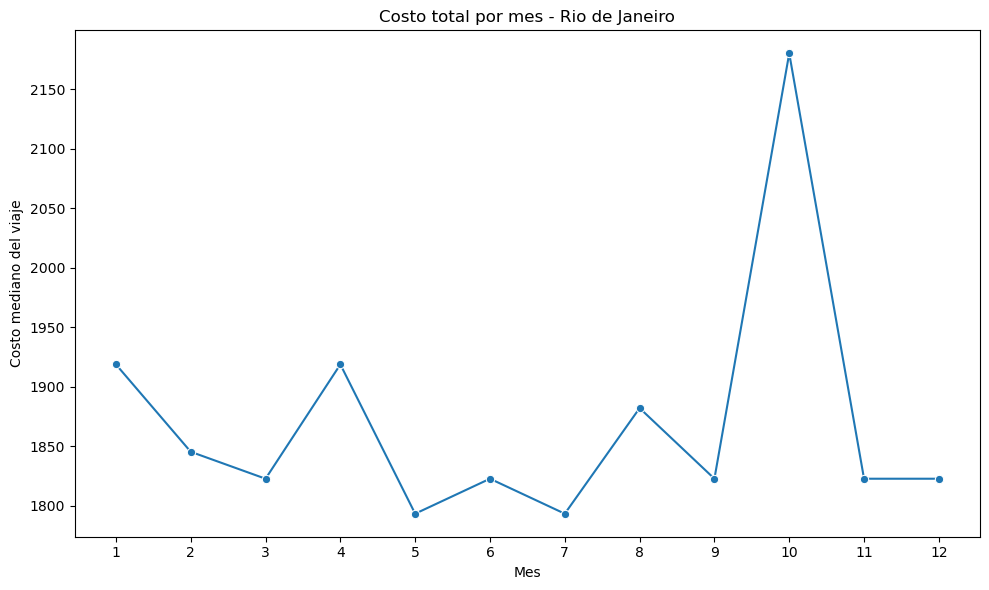

In [69]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=monthly_prices,
    x="month",
    y="total_travel",
    marker="o"
)

plt.title("Costo total por mes - Rio de Janeiro")
plt.xlabel("Mes")
plt.ylabel("Costo mediano del viaje")

plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

## Conclusiones


* El costo del viaje a Rio de Janeiro es relativamente estable durante el año
Oscila aproximadamente entre ~1790 y ~2180

* El mejor momento para viajar a Rio es entre mayo y julio

* El análisis mensual del costo total de viaje a Rio de Janeiro muestra una estacionalidad moderada, con precios relativamente estables durante la mayor parte del año. Sin embargo, se identifica un pico significativo en octubre, lo que sugiere una alta demanda o eventos específicos en ese periodo. Por otro lado, los meses de mayo y julio presentan los costos más bajos, posicionándose como las mejores opciones para viajeros que buscan minimizar gastos.

## Recomendaciones


- Diseñar estrategias de fidelización enfocadas en usuarios recurrentes para maximizar su valor.

- Analizar el comportamiento de usuarios con alta frecuencia para identificar patrones replicables.

- Evaluar otros factores que puedan influir en la disminución de usuarios, como experiencia, disponibilidad o competencia.

- En futuros análisis, incorporar datasets más completos que incluyan conexiones y comportamiento realista de viaje.